In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd

spark = (
    SparkSession.builder.appName("Project 2")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")

    .config("spark.driver.memory", "4g") 
    .config("spark.executor.memory", "2g")

    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/06 01:22:31 WARN Utils: Your hostname, iphone, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/10/06 01:22:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/tavish/projects/Applied ds project 2/venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/10/06 01:22:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# ETL

This notebook joins the BNPL transactions to every other dataset and saves the result to
`curated/transactions.parquet`, with exactly one row per `order_id`.

1. **Read** the internal tables (transactions, consumers, merchants, fraud probabilities) with explicit schemas,
   plus the ABS external data (income, population, and the mesh block files that link postcodes to SA2s).
2. **Clean and join** everything onto the transactions with left joins, so no transaction can silently disappear.
3. **Handle what the joins left empty**: NULLs from the internal tables and missing external data.
4. **Remove invalid amounts and outliers**, and compare the distribution before and after.
5. **Check and save**: one row per `order_id`, and a row count for every step.

## Reading the provided data

In [2]:
# Declaring schemas and reading in the data
import functools
import glob
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from pyspark.sql import types as T

# pyspark 4.2 warns that pandas 3 isn't officially supported yet. The only pandas <-> Spark conversions here
# are small lookup tables and aggregates of plain numbers and strings, which convert correctly.
warnings.filterwarnings("ignore", message="PySpark does not yet fully support pandas")

TABLES = "tables"
EXTERNAL = "external_data"
OUTPUT = "curated/transactions.parquet"

transaction_schema = T.StructType([
    T.StructField("user_id", T.LongType()),
    T.StructField("merchant_abn", T.LongType()),
    T.StructField("dollar_value", T.DoubleType()),
    T.StructField("order_id", T.StringType()),
    T.StructField("order_datetime", T.DateType()),  # partition column, read from the order_datetime=YYYY-MM-DD folders
])

consumer_schema = T.StructType([
    T.StructField("name", T.StringType()),
    T.StructField("address", T.StringType()),
    T.StructField("state", T.StringType()),
    T.StructField("postcode", T.StringType()),  # text, not a number: postcodes starting with 0 lost it (0862 -> 862)
    T.StructField("gender", T.StringType()),
    T.StructField("consumer_id", T.LongType()),
])

user_details_schema = T.StructType([
    T.StructField("user_id", T.LongType()),
    T.StructField("consumer_id", T.LongType()),
])

merchant_schema = T.StructType([
    T.StructField("name", T.StringType()),
    T.StructField("tags", T.StringType()),
    T.StructField("merchant_abn", T.LongType()),
])


def fraud_schema(key):
    return T.StructType([
        T.StructField(key, T.LongType()),
        T.StructField("order_datetime", T.DateType()),
        T.StructField("fraud_probability", T.DoubleType()),
    ])


def read_snapshot(path):
    return (spark.read.schema(transaction_schema).parquet(path)
            .withColumn("snapshot", F.lit(os.path.basename(path))))


# Each snapshot folder is a separate partitioned table, and Spark can't discover partitions across
# several root folders at once, so read them one by one and stack them.
snapshot_paths = sorted(glob.glob(f"{TABLES}/transactions_*_snapshot"))
transactions_raw = functools.reduce(lambda a, b: a.unionByName(b), [read_snapshot(p) for p in snapshot_paths])

# FAILFAST: stop on any CSV value that doesn't fit the schema instead of quietly turning it into NULL
consumers_raw = spark.read.csv(f"{TABLES}/tbl_consumer.csv", sep="|", header=True,
                               schema=consumer_schema, mode="FAILFAST")
user_details = spark.read.schema(user_details_schema).parquet(f"{TABLES}/consumer_user_details.parquet")
merchants_raw = spark.read.schema(merchant_schema).parquet(f"{TABLES}/tbl_merchants.parquet")
consumer_fraud_raw = spark.read.csv(f"{TABLES}/consumer_fraud_probability.csv", header=True,
                                    schema=fraud_schema("user_id"), mode="FAILFAST")
merchant_fraud_raw = spark.read.csv(f"{TABLES}/merchant_fraud_probability.csv", header=True,
                                    schema=fraud_schema("merchant_abn"), mode="FAILFAST")

raw_tables = {
    "transactions (3 snapshots)": transactions_raw,
    "tbl_consumer": consumers_raw,
    "consumer_user_details": user_details,
    "tbl_merchants": merchants_raw,
    "consumer_fraud_probability": consumer_fraud_raw,
    "merchant_fraud_probability": merchant_fraud_raw,
}
display(pd.DataFrame({"rows": {name: df.count() for name, df in raw_tables.items()},
                      "columns": {name: len(df.columns) for name, df in raw_tables.items()}}))

,rows,columns
transactions (3 snapshots),14195505,6
tbl_consumer,499999,6
consumer_user_details,499999,2
tbl_merchants,4026,3
consumer_fraud_probability,34864,3
merchant_fraud_probability,114,3


A few things in the raw tables shape the cleaning below:
- `order_id` is unique across all three snapshots and the transaction columns have no NULLs.
- The third snapshot is labelled `20220228_20220828` but runs to 2022-10-26. Those later rows look like ordinary
  transactions, so they're kept. 
- Postcodes were stored as numbers, so postcodes starting with 0 (all of the NT, and the ACT's 02xx) lost their
  leading zero (`0862` became `862`). They're padded back to 4 digits before joining to the ABS data.
- The consumer fraud file has exact duplicate rows. Left in, they would double those transactions in the join.

In [3]:
snapshot_end = F.to_date(F.regexp_extract("snapshot", r"_(\d{8})_snapshot", 1), "yyyyMMdd")
display(transactions_raw.groupBy("snapshot").agg(
    F.count("*").alias("rows"),
    F.min("order_datetime").alias("first_order"),
    F.max("order_datetime").alias("last_order"),
    F.sum((F.col("order_datetime") > snapshot_end).cast("int")).alias("rows_after_snapshot_end"),
).orderBy("snapshot").toPandas())

n_transactions_raw = transactions_raw.count()
raw_checks = {
    "duplicate order_id": n_transactions_raw - transactions_raw.select("order_id").distinct().count(),
    "transaction rows with any NULL": n_transactions_raw - transactions_raw.dropna().count(),
    "consumers with a 3-digit postcode": consumers_raw.filter(F.length(F.trim("postcode")) < 4).count(),
    "consumer fraud: exact duplicate rows": consumer_fraud_raw.count() - consumer_fraud_raw.distinct().count(),
    "merchant fraud: exact duplicate rows": merchant_fraud_raw.count() - merchant_fraud_raw.distinct().count(),
}
display(pd.Series(raw_checks, name="count").to_frame())
display(pd.DataFrame({name: df.agg(F.min("order_datetime").alias("first"), F.max("order_datetime").alias("last"))
                                .toPandas().iloc[0]
                      for name, df in [("consumer fraud", consumer_fraud_raw), ("merchant fraud", merchant_fraud_raw)]}))

,snapshot,rows,first_order,last_order,rows_after_snapshot_end
0,transactions_20210228_20210827_snapshot,3643266,2021-02-28,2021-08-27,0
1,transactions_20210828_20220227_snapshot,4508106,2021-08-28,2022-02-27,0
2,transactions_20220228_20220828_snapshot,6044133,2022-02-28,2022-10-26,1634128


,count
duplicate order_id,0
transaction rows with any NULL,0
consumers with a 3-digit postcode,7909
consumer fraud: exact duplicate rows,99
merchant fraud: exact duplicate rows,0


,consumer fraud,merchant fraud
first,2021-02-28,2021-03-25
last,2022-02-27,2022-02-27


### External data

| File | What it holds | Geography |
|---|---|---|
| `income/Table 1 ... 2018-19 to 2022-23.xlsx` | earners, median and mean income for each financial year; `np` = not published | SA2, plus state rows |
| `population/32180DS0001_2021-22r.xlsx`, `..._2022-23.xlsx` | estimated resident population (ERP) at 30 June 2021 and 2022, and 2022 (revised) and 2023 | SA2 |
| `shapefile/MB_2021_AUST.xlsx` | the SA2 of every mesh block, the smallest ABS area | mesh block → SA2 |
| `shapefile/POA_2021_AUST.xlsx` | the postal area (postcode) of every mesh block | mesh block → postcode |

Consumers only have a postcode, and postcodes don't nest inside SA2s. Every mesh block has both a postcode and an
SA2, though, so the two allocation files show exactly how they overlap. Each postcode is assigned the SA2 that holds most
of its *residential* mesh blocks (where people live), and the consumer gets that SA2's income and population.
The SA2 boundary shapefile isn't needed for the join: the allocation files give a deterministic mesh-block correspondence; assigning a postcode to one SA2 is an approximation.
It's only useful for drawing maps later.

The transactions span three financial years (Jul–Jun). Each transaction gets the income for its own financial year,
and the population estimate at 30 June when that year ends. For 2022 both population releases have an estimate,
and the newer, revised one is used.

In [4]:
INCOME_FILE = f"{EXTERNAL}/income/Table 1 - Total income, earners and summary statistics by geography, 2018-19 to 2022-23.xlsx"
POPULATION_FILES = [f"{EXTERNAL}/population/32180DS0001_2021-22r.xlsx", f"{EXTERNAL}/population/32180DS0001_2022-23.xlsx"]
MESH_BLOCK_FILE = f"{EXTERNAL}/shapefile/MB_2021_AUST.xlsx"
POSTAL_AREA_FILE = f"{EXTERNAL}/shapefile/POA_2021_AUST.xlsx"

# financial year -> the 30 June population estimate at the end of that year
FINANCIAL_YEARS = {"2020-21": 2021, "2021-22": 2022, "2022-23": 2023}
STATES = {"New South Wales": "NSW", "Victoria": "VIC", "Queensland": "QLD", "South Australia": "SA",
          "Western Australia": "WA", "Tasmania": "TAS", "Northern Territory": "NT",
          "Australian Capital Territory": "ACT"}
SA2_STATE_DIGIT = {"1": "NSW", "2": "VIC", "3": "QLD", "4": "SA", "5": "WA", "6": "TAS", "7": "NT", "8": "ACT"}

# --- Income (ABS Personal Income in Australia: one row per SA2, with a total row per state)
income_years = ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]
income_table = pd.read_excel(INCOME_FILE, sheet_name="Table 1.4", header=None, skiprows=7,
                             usecols=range(27), dtype=object)
income_table.columns = ["code", "name"] + [f"{measure}_{fy}" for measure in
                                           ["earners", "median_age", "sum", "median_income", "mean_income"]
                                           for fy in income_years]
income_table["code"] = income_table["code"].astype(str).str.strip()


def income_by_year(rows, key):
    """One row per area and financial year. 'np' (not published) becomes NaN."""
    frames = []
    for fy in FINANCIAL_YEARS:
        frame = rows[[key, f"median_income_{fy}", f"mean_income_{fy}"]].copy()
        frame.columns = [key, "median_income", "mean_income"]
        frame.insert(1, "financial_year", fy)
        frames.append(frame)
    out = pd.concat(frames, ignore_index=True)
    for column in ["median_income", "mean_income"]:
        out[column] = pd.to_numeric(out[column], errors="coerce").astype("float64")
    return out


sa2_income = income_by_year(income_table[income_table["code"].str.fullmatch(r"\d{9}")]
                            .rename(columns={"code": "sa2_code"}), "sa2_code")
state_income = income_by_year(income_table[income_table["code"].isin(list(STATES))]
                              .assign(state=lambda d: d["code"].map(STATES)), "state")


# --- Population (ABS Regional population: Tables 1-9 are one per state/territory)
def read_sa2_population(path):
    """SA2 estimated resident population. The two releases lay their columns out differently,
    so find the 'SA2 code' header row instead of hard-coding positions."""
    frames = []
    for table in range(1, 10):
        sheet = pd.read_excel(path, sheet_name=f"Table {table}", header=None, dtype=object)
        header_row = sheet.index[sheet.eq("SA2 code").any(axis=1)][0]
        code_col = sheet.columns[sheet.loc[header_row].eq("SA2 code")][0]
        erp_cols = [code_col + 2, code_col + 3]                   # the two "ERP at 30 June" columns
        years = sheet.loc[header_row - 1, erp_cols].astype(int)   # e.g. 2021, 2022
        body = sheet.loc[header_row + 1:, [code_col, *erp_cols]]
        body.columns = ["sa2_code", *[f"erp_{year}" for year in years]]
        frames.append(body[body["sa2_code"].astype(str).str.fullmatch(r"\d{9}")])
    population = pd.concat(frames, ignore_index=True)
    population["sa2_code"] = population["sa2_code"].astype(str)
    return population.set_index("sa2_code").apply(pd.to_numeric)


population_2122, population_2223 = (read_sa2_population(path) for path in POPULATION_FILES)
# newest estimate for each date: 2021 from the 2021-22 release; 2022 (revised) and 2023 from the 2022-23 release
sa2_erp = pd.concat([population_2122[["erp_2021"]], population_2223[["erp_2022", "erp_2023"]]], axis=1)
sa2_population = (sa2_erp.rename(columns={f"erp_{year}": fy for fy, year in FINANCIAL_YEARS.items()})
                  .rename_axis("sa2_code").reset_index()
                  .melt(id_vars="sa2_code", var_name="financial_year", value_name="population"))

# --- Mesh blocks: each one has an SA2 (MB file) and a postcode (POA file). 
mesh_blocks = pd.read_excel(MESH_BLOCK_FILE, dtype=str,
                            usecols=["MB_CODE_2021", "MB_CATEGORY_2021", "SA2_CODE_2021", "SA2_NAME_2021"])
postal_areas = pd.read_excel(POSTAL_AREA_FILE, dtype=str, usecols=["MB_CODE_2021", "POA_CODE_2021"])

display(pd.Series({
    "SA2 income (SA2 x financial year)": len(sa2_income),
    "state income (state x financial year)": len(state_income),
    "SA2 population (SA2 x financial year)": len(sa2_population),
    "mesh blocks (MB file)": len(mesh_blocks),
    "mesh blocks (POA file)": len(postal_areas),
}, name="rows").to_frame())
display(sa2_income.groupby("financial_year")["median_income"].apply(lambda s: s.isna().sum())
        .rename("SA2s with unpublished (np) income").to_frame().T)

,rows
SA2 income (SA2 x financial year),7350
state income (state x financial year),24
SA2 population (SA2 x financial year),7362
mesh blocks (MB file),368286
mesh blocks (POA file),368286


financial_year,2020-21,2021-22,2022-23
SA2s with unpublished (np) income,48,48,45


In [5]:
# --- Postcode -> SA2
mb = mesh_blocks.merge(postal_areas, on="MB_CODE_2021", how="inner", validate="one_to_one")
# Keep real places only: this drops the 'No usual address', 'Migratory - Offshore - Shipping' and outside-Australia
# codes (postcodes ZZZZ, 9494 and 9797), which are exactly the SA2s without a population estimate.
mb = mb[mb["SA2_CODE_2021"].isin(sa2_erp.index)]
mb["residential"] = mb["MB_CATEGORY_2021"].eq("Residential")

overlap = (mb.groupby(["POA_CODE_2021", "SA2_CODE_2021", "SA2_NAME_2021"], as_index=False)
             .agg(residential_mesh_blocks=("residential", "sum"), mesh_blocks=("MB_CODE_2021", "size")))
overlap["share_of_postcode"] = (overlap["residential_mesh_blocks"]
                                / overlap.groupby("POA_CODE_2021")["residential_mesh_blocks"].transform("sum"))

# Each postcode takes the SA2 holding most of its residential mesh blocks. Postcodes with none
# (farmland, national parks) take the SA2 holding most of their mesh blocks of any kind.
postcode_sa2 = (overlap.sort_values(["POA_CODE_2021", "residential_mesh_blocks", "mesh_blocks", "SA2_CODE_2021"],
                                    ascending=[True, False, False, True])
                .drop_duplicates("POA_CODE_2021")
                .rename(columns={"POA_CODE_2021": "postcode", "SA2_CODE_2021": "sa2_code", "SA2_NAME_2021": "sa2_name"}))

print(f"{len(postcode_sa2):,} postcodes. Each overlaps {overlap.groupby('POA_CODE_2021').size().median():.0f} SA2s "
      f"(median); the chosen SA2 holds a median {postcode_sa2['share_of_postcode'].median():.0%} "
      f"of the postcode's residential mesh blocks.")

# --- External values per postcode and financial year (income NaN where the SA2's income is 'np')
postcode_external = (postcode_sa2[["postcode", "sa2_code", "sa2_name"]]
                     .merge(pd.DataFrame({"financial_year": list(FINANCIAL_YEARS)}), how="cross")
                     .merge(sa2_income, on=["sa2_code", "financial_year"], how="left")
                     .merge(sa2_population, on=["sa2_code", "financial_year"], how="left"))
assert postcode_external["population"].notna().all()  # every real SA2 has a population estimate
postcode_external["population"] = postcode_external["population"].astype("int64")

# --- State-level values for consumers whose postcode can't be placed in an SA2 
sa2_population["state"] = sa2_population["sa2_code"].str[0].map(SA2_STATE_DIGIT)
state_population = (sa2_population[sa2_population["population"] > 0].dropna(subset=["state"])
                    .groupby(["state", "financial_year"], as_index=False)["population"].median()
                    .assign(population=lambda d: d["population"].round().astype("int64")))
state_external = (state_income.merge(state_population, on=["state", "financial_year"], validate="one_to_one")
                  .rename(columns={"median_income": "state_median_income", "mean_income": "state_mean_income",
                                   "population": "state_population"}))


def to_spark(pdf):
    """pandas 3 keeps text in pyarrow chunked arrays, which pyspark 4.2's Arrow conversion can't read yet.
       Plain Python strings convert cleanly, and NaN arrives in Spark as NULL."""
    text_columns = [c for c in pdf.columns if pd.api.types.is_string_dtype(pdf[c])]
    return spark.createDataFrame(pdf.astype({c: object for c in text_columns}))


postcode_external_sdf = to_spark(postcode_external)
state_external_sdf = to_spark(state_external)
display(state_external.pivot(index="state", columns="financial_year", values="state_median_income"))

2,641 postcodes. Each overlaps 2 SA2s (median); the chosen SA2 holds a median 100% of the postcode's residential mesh blocks.


financial_year,2020-21,2021-22,2022-23
state,,,
ACT,69743.0,72115.0,75643.0
NSW,53905.0,55105.0,58909.0
NT,62409.0,65301.0,66831.0
QLD,51557.0,54076.0,56708.0
SA,50976.0,53353.0,55782.0
TAS,48161.0,50645.0,53479.0
VIC,52218.0,54708.0,57907.0
WA,56415.0,59426.0,62207.0


## Cleaning and combining the datasets

Every join is a **left join** onto the transactions, so a transaction with no match keeps its row and gets NULLs.
That makes it possible to count the NULLs and choose what to do with them, instead of losing rows silently
the way an inner join would. 

In [6]:
# Cleaning and combining all the datasets into one row per transaction and removing outliers

# --- Merchants: tags look like "((furniture, home furnishings ...), (e), (take rate: 0.18))", with () and []
#     mixed at random and random capital letters, so lower-case them and pull out the three parts.
TAG_PATTERN = r"^[\[(]\s*[\[(](.+)[\])]\s*,\s*[\[(]\s*([a-e])\s*[\])]\s*,\s*[\[(]\s*take rate:\s*([0-9.]+)\s*[\])]\s*[\])]$"
merchants = (merchants_raw
             .withColumn("tags", F.lower(F.trim("tags")))
             .select("merchant_abn",
                     F.col("name").alias("merchant_name"),
                     F.regexp_extract("tags", TAG_PATTERN, 1).alias("category"),
                     F.regexp_extract("tags", TAG_PATTERN, 2).alias("revenue_level"),
                     F.regexp_extract("tags", TAG_PATTERN, 3).cast("double").alias("take_rate"))
             .withColumn("category", F.regexp_replace(F.trim("category"), r"\s+", " "))
             .withColumn("category", F.regexp_replace("category", " ,", ","))           # fixes "programming , data"
             .withColumn("category", F.regexp_replace("category", "rent al", "rental")))  # typo in the source tags
assert merchants.filter((F.col("category") == "") | F.col("take_rate").isNull()).count() == 0, "unparsed tags"

# --- Consumers: restore the leading zero (862 -> 0862) and attach user_id. Names and street addresses are
#     dropped.
consumers = (consumers_raw
             .withColumn("postcode", F.lpad(F.trim("postcode"), 4, "0"))
             .join(user_details, on="consumer_id", how="inner")
             .select("user_id", "consumer_id", "state", "postcode", "gender"))

# --- Fraud probabilities: drop the exact duplicate rows so each (id, date) appears once and can't double a transaction
consumer_fraud = consumer_fraud_raw.dropDuplicates().withColumnRenamed("fraud_probability", "consumer_fraud_probability")
merchant_fraud = merchant_fraud_raw.dropDuplicates().withColumnRenamed("fraud_probability", "merchant_fraud_probability")
for fraud, key in [(consumer_fraud, "user_id"), (merchant_fraud, "merchant_abn")]:
    assert fraud.count() == fraud.select(key, "order_datetime").distinct().count()

# --- Transactions: tag each one with its financial year (1 July - 30 June) to pick the matching external data
fy_start = F.when(F.month("order_datetime") >= 7, F.year("order_datetime")).otherwise(F.year("order_datetime") - 1)
transactions = (transactions_raw
                .withColumn("financial_year", F.format_string("%d-%02d", fy_start, (fy_start + 1) % 100))
                .drop("snapshot"))

joined = (transactions
          .join(F.broadcast(consumers), on="user_id", how="left")
          .join(F.broadcast(merchants), on="merchant_abn", how="left")
          .join(F.broadcast(consumer_fraud), on=["user_id", "order_datetime"], how="left")
          .join(F.broadcast(merchant_fraud), on=["merchant_abn", "order_datetime"], how="left")
          .join(F.broadcast(postcode_external_sdf), on=["postcode", "financial_year"], how="left")
          .cache())

n_joined = joined.count()
assert n_joined == n_transactions_raw, "a join duplicated or dropped transactions"
assert joined.select("order_id").distinct().count() == n_joined
print(f"{n_joined:,} rows after joining = {n_transactions_raw:,} transactions, one row per order_id")

14,195,505 rows after joining = 14,195,505 transactions, one row per order_id


### NULL values after joining

Counting NULLs in every column of the joined data shows which joins came back empty, and for how many transactions.

In [7]:
COLUMN_SOURCE = {
    "order_id": "transactions", "order_datetime": "transactions", "user_id": "transactions",
    "merchant_abn": "transactions", "dollar_value": "transactions", "financial_year": "transactions",
    "consumer_id": "consumer_user_details", "state": "tbl_consumer", "postcode": "tbl_consumer", "gender": "tbl_consumer",
    "merchant_name": "tbl_merchants", "category": "tbl_merchants", "revenue_level": "tbl_merchants",
    "take_rate": "tbl_merchants",
    "consumer_fraud_probability": "consumer_fraud_probability", "merchant_fraud_probability": "merchant_fraud_probability",
    "sa2_code": "external (postcode -> SA2)", "sa2_name": "external (postcode -> SA2)",
    "median_income": "external (income)", "mean_income": "external (income)", "population": "external (population)",
}


def null_report(df, n_rows):
    counts = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]).toPandas().iloc[0]
    ordered = [c for c in COLUMN_SOURCE if c in df.columns] + [c for c in df.columns if c not in COLUMN_SOURCE]
    return (pd.DataFrame({"source": pd.Series(COLUMN_SOURCE), "null_rows": counts.astype("int64")})
            .loc[ordered]
            .assign(pct_of_rows=lambda d: (100 * d["null_rows"] / n_rows).round(2)))


nulls_after_join = null_report(joined, n_joined)
display(nulls_after_join)

,source,null_rows,pct_of_rows
order_id,transactions,0,0.00
order_datetime,transactions,0,0.00
user_id,transactions,0,0.00
merchant_abn,transactions,0,0.00
dollar_value,transactions,0,0.00
financial_year,transactions,0,0.00
consumer_id,consumer_user_details,0,0.00
state,tbl_consumer,0,0.00
postcode,tbl_consumer,0,0.00
gender,tbl_consumer,0,0.00


The NULLs come from three places, and each one is handled differently:

- **Merchant columns (`merchant_name`, `category`, `revenue_level`, `take_rate`)**: some merchant ABNs in the
  transactions aren't in `tbl_merchants`. With no merchant record (no category, revenue level or take rate)
  those transactions can't be used to rank merchants, so **they're dropped**.
- **Fraud probabilities**: the fraud files only score some user-days and merchant-days, so most transactions have
  none. NULL here means "never assessed", which isn't the same as 0% fraud, so **they're left as NULL**. Filling
  them would invent a score. (Neither file covers anything after 2022-02-27.)
- **External columns**: a consumer postcode didn't match an ABS postal area, or the SA2's income isn't
  published. 

No consumer columns are NULL: every `user_id` in the transactions has a consumer record.

In [8]:
unknown_merchant = joined.filter(F.col("merchant_name").isNull())
unknown_merchant_summary = unknown_merchant.agg(
    F.count("*").alias("transactions"),
    F.countDistinct("merchant_abn").alias("merchant_abns"),
    F.sum("dollar_value").alias("dollar_value"),
).toPandas().iloc[0]
total_value = joined.agg(F.sum("dollar_value")).first()[0]

n_unknown_rows = int(unknown_merchant_summary["transactions"])
n_unknown_abns = int(unknown_merchant_summary["merchant_abns"])
unknown_value_share = unknown_merchant_summary["dollar_value"] / total_value

with_merchant = joined.filter(F.col("merchant_name").isNotNull())
n_with_merchant = n_joined - n_unknown_rows
n_consumer_fraud = n_joined - int(nulls_after_join.loc["consumer_fraud_probability", "null_rows"])
n_merchant_fraud = n_joined - int(nulls_after_join.loc["merchant_fraud_probability", "null_rows"])

print(f"Unknown merchants: {n_unknown_rows:,} transactions ({n_unknown_rows / n_joined:.2%}) from {n_unknown_abns} ABNs, "
      f"{unknown_value_share:.1%} of total dollar value -> dropped, {n_with_merchant:,} rows left")
print(f"Consumer fraud probability present for {n_consumer_fraud:,} transactions, merchant fraud probability "
      f"for {n_merchant_fraud:,} -> the rest stay NULL")

Unknown merchants: 580,830 transactions (4.09%) from 396 ABNs, 8.6% of total dollar value -> dropped, 13,614,675 rows left
Consumer fraud probability present for 80,348 transactions, merchant fraud probability for 4,059 -> the rest stay NULL


### Missing data after joining the external dataset

There are three ways a transaction can miss its external values:

1. **The consumer's postcode isn't an ABS postal area.** PO box and large-volume-receiver postcodes have no land
   area, so there's no SA2 to match. That covers PO box ranges (NSW 1xxx, WA 68xx–69xx, VIC 8xxx, QLD 9xxx),
   GPO boxes such as 2001 and 3001, and universities such as 2006 and 3010. These examples explain many unmatched codes, but a missing match alone does not establish its cause.
   ABS postal areas approximate postcodes and can also omit some street-delivery postcodes.
2. **The SA2's income is `np`** (not published, suppressed by the ABS for privacy). This affects only a handful of
   postcodes.
3. **Leading zeros (fixed)** Joining on the raw postcode would have silently
   missed every NT consumer (and the ACT's 02xx postcodes), because `0862` was stored as `862`. Padding to four
   digits fixed it before the join. The count below is how many transactions it saved.

In [9]:
external_status = (with_merchant
                   .withColumn("external_status",
                               F.when(F.col("sa2_code").isNull(), "postcode not an ABS postal area (PO box etc.)")
                               .when(F.col("median_income").isNull(), "SA2 income not published (np)")
                               .otherwise("matched")))
missing_external = (external_status.groupBy("external_status")
                    .agg(F.count("*").alias("transactions"), F.countDistinct("user_id").alias("users"))
                    .toPandas().set_index("external_status").sort_values("transactions", ascending=False))
missing_external["pct_of_transactions"] = (100 * missing_external["transactions"] / n_with_merchant).round(2)
display(missing_external)

no_postal_area = external_status.filter(F.col("sa2_code").isNull())
display(no_postal_area.groupBy("state").agg(F.count("*").alias("transactions"),
                                            F.countDistinct("postcode").alias("postcodes"))
        .orderBy(F.desc("transactions")).toPandas().set_index("state").T)

consumers_without_area = consumers.join(postcode_external_sdf.select("postcode").distinct(), "postcode", "left_anti")
n_consumers_without_area = consumers_without_area.count()
n_postcodes_without_area = consumers_without_area.select("postcode").distinct().count()

padded = with_merchant.filter(F.col("postcode").startswith("0"))  # postcodes that were 3 digits in the CSV
n_saved_by_padding = padded.filter(F.col("sa2_code").isNotNull()).count()

n_no_area_rows = int(missing_external.loc["postcode not an ABS postal area (PO box etc.)", "transactions"])
n_no_area_users = int(missing_external.loc["postcode not an ABS postal area (PO box etc.)", "users"])
n_np_rows = int(missing_external["transactions"].get("SA2 income not published (np)", 0))
n_users = with_merchant.select("user_id").distinct().count()
print(f"Consumers whose postcode isn't an ABS postal area: {n_consumers_without_area:,} of "
      f"{consumers.count():,} ({n_postcodes_without_area} distinct postcodes)")
print(f"Transactions that matched only because the postcode was padded to 4 digits: {n_saved_by_padding:,}")

,transactions,users,pct_of_transactions
external_status,,,
matched,11350857,20081,83.37
postcode not an ABS postal area (PO box etc.),2244225,3970,16.48
SA2 income not published (np),19593,41,0.14


state,NSW,WA,VIC,QLD,NT,SA,ACT,TAS
transactions,1275938,481281,240571,114717,59966,30509,21506,19737
postcodes,297,116,53,29,15,7,5,5


Consumers whose postcode isn't an ABS postal area: 83,181 of 499,999 (527 distinct postcodes)
Transactions that matched only because the postcode was padded to 4 digits: 134,001


**What's done about it.** Dropping 1 in 6 transactions would bias everything downstream, and leaving NULLs only pushes
the problem to the next step. For these consumers the state is the finest geography known, so:

- `median_income` and `mean_income` are filled with the ABS figure for the consumer's **state** in the same
  financial year.
- `population` is filled with the **median SA2 population** in that state (a typical SA2), since an SA2's
  population is what every other row holds.
- `income_imputed` and `population_imputed` record which rows were filled, so later analysis can exclude or
  down-weight them. `sa2_code` and `sa2_name` stay NULL: there's no SA2 to name.

In [10]:
transactions_ext = (with_merchant
                    .join(F.broadcast(state_external_sdf), on=["state", "financial_year"], how="left")
                    .withColumn("income_imputed", F.col("median_income").isNull())
                    .withColumn("population_imputed", F.col("population").isNull())
                    .withColumn("median_income", F.coalesce("median_income", "state_median_income"))
                    .withColumn("mean_income", F.coalesce("mean_income", "state_mean_income"))
                    .withColumn("population", F.coalesce("population", "state_population"))
                    .drop("state_median_income", "state_mean_income", "state_population"))

imputation = transactions_ext.agg(
    F.sum(F.col("income_imputed").cast("int")).alias("income_imputed"),
    F.sum(F.col("population_imputed").cast("int")).alias("population_imputed"),
    F.sum(F.col("median_income").isNull().cast("int")).alias("median_income_still_null"),
    F.sum(F.col("population").isNull().cast("int")).alias("population_still_null"),
).toPandas().iloc[0]
n_income_imputed, n_population_imputed = int(imputation["income_imputed"]), int(imputation["population_imputed"])
assert imputation["median_income_still_null"] == 0 and imputation["population_still_null"] == 0
display(imputation.rename("transactions").to_frame())

,transactions
income_imputed,2263818
population_imputed,2244225
median_income_still_null,0
population_still_null,0


### Outliers

There are two separate problems with `dollar_value`:

- **Invalid amounts.** Some values are below one cent (the smallest is about $0.0000001). They can't be charged,
  so they're errors, not just unusual purchases.
- **Outliers.** Price levels differ hugely between merchants: the median sale is about $25 at tent shops and
  about $7,700 at jewellers, so a $3,000 sale is routine for one merchant and extreme for another. One global
  cut-off can't handle that. So a value is judged against **its own merchant's** transactions, using Tukey's far-out fences:
  outside `[Q1 - 3·IQR, Q3 + 3·IQR]` of that merchant's amounts. Each merchant's amounts are right-skewed,
  so the usual 1.5·IQR fence would cut a slice of every merchant's normal upper tail. The 3·IQR fence removes
  only values that are extreme even allowing for that skew.

In [11]:
MIN_AMOUNT = 0.01   # one cent
IQR_MULTIPLIER = 3  # Tukey's "far out" fence

fences = (transactions_ext.filter(F.col("dollar_value") >= MIN_AMOUNT)
          .groupBy("merchant_abn")
          .agg(F.percentile("dollar_value", [0.25, 0.5, 0.75]).alias("q"))  # exact quartiles per merchant
          .select("merchant_abn",
                  F.col("q")[0].alias("q1"), F.col("q")[1].alias("merchant_median"), F.col("q")[2].alias("q3"))
          .withColumn("lower_fence", F.col("q1") - IQR_MULTIPLIER * (F.col("q3") - F.col("q1")))
          .withColumn("upper_fence", F.col("q3") + IQR_MULTIPLIER * (F.col("q3") - F.col("q1")))
          .cache())

flagged = (transactions_ext
           .join(F.broadcast(fences), on="merchant_abn", how="left")
           .withColumn("removal_reason",
                       F.when(F.col("dollar_value") < MIN_AMOUNT, "below one cent")
                       .when(F.col("dollar_value") < F.col("lower_fence"), "merchant outlier (low)")
                       .when(F.col("dollar_value") > F.col("upper_fence"), "merchant outlier (high)"))
           .cache())

valid = flagged.filter(F.col("dollar_value") >= MIN_AMOUNT)
merchant_skew = (valid.groupBy("merchant_abn").agg(F.skewness("dollar_value").alias("skew"))
                 .filter(F.col("skew").isNotNull() & ~F.isnan("skew")))
median_merchant_skew = merchant_skew.approxQuantile("skew", [0.5], 0.0)[0]
iqr = F.col("q3") - F.col("q1")
share_at_1_5_iqr = valid.filter((F.col("dollar_value") < F.col("q1") - 1.5 * iqr)
                                | (F.col("dollar_value") > F.col("q3") + 1.5 * iqr)).count() / n_with_merchant
print(f"Median skewness of a merchant's amounts: {median_merchant_skew:.2f} (0 = symmetric). "
      f"A 1.5 x IQR fence would remove {share_at_1_5_iqr:.2%} of transactions; the 3 x IQR fence removes:")

removed_summary = (flagged.groupBy(F.coalesce("removal_reason", F.lit("kept")).alias("outcome"))
                   .agg(F.count("*").alias("transactions"), F.min("dollar_value").alias("min_value"),
                        F.max("dollar_value").alias("max_value"))
                   .toPandas().set_index("outcome"))
removed_summary["pct"] = (100 * removed_summary["transactions"] / n_with_merchant).round(3)
display(removed_summary)
joined.unpersist()  # `flagged` is cached now, so free the memory held by the joined table

by_category = (flagged.groupBy("category")
               .agg(F.count("*").alias("transactions"),
                    F.sum(F.col("removal_reason").isNotNull().cast("int")).alias("removed"),
                    F.percentile_approx("dollar_value", 0.5).alias("median_value"))
               .withColumn("pct_removed", F.round(100 * F.col("removed") / F.col("transactions"), 2))
               .orderBy("median_value").toPandas().set_index("category"))
display(by_category)

26/10/06 01:26:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


26/10/06 01:28:28 WARN MemoryStore: Not enough space to cache rdd_448_22 in memory! (computed 54.9 MiB so far)


Median skewness of a merchant's amounts: 1.30 (0 = symmetric). A 1.5 x IQR fence would remove 3.26% of transactions; the 3 x IQR fence removes:


26/10/06 01:28:32 WARN MemoryStore: Not enough space to cache rdd_448_19 in memory! (computed 54.9 MiB so far)


,transactions,min_value,max_value,pct
outcome,,,,
merchant outlier (high),63784,3.657609e+01,105193.885789,0.468
kept,13549875,1.003123e-02,77134.214605,99.524
below one cent,1014,9.756658e-08,0.009981,0.007
merchant outlier (low),2,3.624357e+02,9234.908758,0.000


,transactions,removed,median_value,pct_removed
category,,,,
tent and awning shops,1816892,6938,24.665290,0.38
"opticians, optical goods, and eyeglasses",843886,6225,40.882928,0.74
"florists supplies, nursery stock, and flowers",881764,3730,45.778927,0.42
"watch, clock, and jewelry repair shops",1031475,4524,47.875937,0.44
"digital goods: books, movies, music",1283753,5989,51.867182,0.47
"gift, card, novelty, and souvenir shops",1640011,8172,55.746618,0.50
"computers, computer peripheral equipment, and software",718424,3436,63.578929,0.48
"cable, satellite, and other pay television and radio services",957060,4069,64.323648,0.43
artist supply and craft shops,472178,3284,64.632637,0.70


In [12]:
def value_summary(df):
    """Exact summary statistics of dollar_value (approxQuantile with relativeError=0 is exact)."""
    stats = df.agg(F.count("dollar_value").alias("count"), F.mean("dollar_value").alias("mean"),
                   F.stddev("dollar_value").alias("stddev"), F.min("dollar_value").alias("min"),
                   F.max("dollar_value").alias("max")).first().asDict()
    percentiles = {"1%": 0.01, "25%": 0.25, "50%": 0.5, "75%": 0.75, "99%": 0.99}
    stats.update(zip(percentiles, df.approxQuantile("dollar_value", list(percentiles.values()), 0.0)))
    order = ["count", "mean", "stddev", "min", "1%", "25%", "50%", "75%", "99%", "max"]
    return pd.Series(stats)[order].astype(float)


kept = flagged.filter(F.col("removal_reason").isNull())
relative = F.col("dollar_value") / F.col("merchant_median")
before_after = pd.DataFrame({"before": value_summary(flagged), "after": value_summary(kept)})
before_after.loc["max / merchant median"] = [df.agg(F.max(relative)).first()[0] for df in (flagged, kept)]
display(before_after.round(2))

,before,after
count,13614675.00,13549875.00
mean,158.44,156.03
stddev,461.49,448.63
min,0.00,0.01
1%,1.22,1.22
25%,25.64,25.51
50%,60.92,60.45
75%,147.51,145.83
99%,1483.14,1449.09
max,105193.89,77134.21


26/10/06 01:30:40 WARN MemoryStore: Not enough space to cache rdd_448_7 in memory! (computed 104.7 MiB so far)


26/10/06 01:30:42 WARN MemoryStore: Not enough space to cache rdd_448_11 in memory! (computed 54.5 MiB so far)


26/10/06 01:30:44 WARN MemoryStore: Not enough space to cache rdd_448_8 in memory! (computed 107.2 MiB so far)
26/10/06 01:30:44 WARN MemoryStore: Not enough space to cache rdd_448_11 in memory! (computed 91.4 MiB so far)


26/10/06 01:30:48 WARN MemoryStore: Not enough space to cache rdd_448_12 in memory! (computed 54.6 MiB so far)


26/10/06 01:30:48 WARN MemoryStore: Not enough space to cache rdd_448_15 in memory! (computed 107.9 MiB so far)


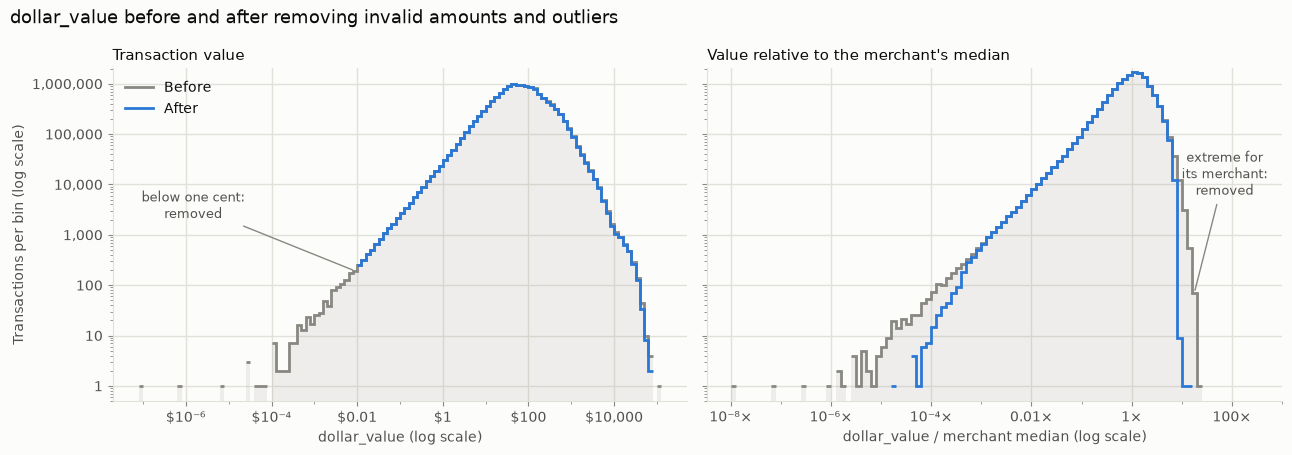

In [13]:
BIN_WIDTH = 0.1  # bins are 0.1 wide on a log10 scale
SURFACE, INK, INK_SECONDARY, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BEFORE_COLOR, AFTER_COLOR = "#898781", "#2a78d6"  # context in grey, what's kept in blue
SUPERSCRIPT = str.maketrans("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹")


def log_histogram(df, column):
    """Counts per log10 bin, computed in Spark so millions of rows never leave the cluster."""
    return (df.select(F.floor(F.log10(column) / BIN_WIDTH).cast("int").alias("bin"))
              .filter(F.col("bin").isNotNull())
              .groupBy("bin").count().toPandas().set_index("bin")["count"])


def tick_label(x, prefix="", suffix=""):
    """$0.01, $1, $10,000 ... and powers of ten below one cent."""
    if x >= 0.01:
        return prefix + f"{x:,.2f}".rstrip("0").rstrip(".") + suffix
    return prefix + "10" + str(round(np.log10(x))).translate(SUPERSCRIPT) + suffix


def draw(ax, before, after, title, xlabel, tick_format, note, note_side):
    bins = np.arange(min(before.index.min(), after.index.min()), max(before.index.max(), after.index.max()) + 1)
    edges = 10.0 ** (np.append(bins, bins[-1] + 1) * BIN_WIDTH)
    centers = 10.0 ** ((bins + 0.5) * BIN_WIDTH)
    before_counts = before.reindex(bins, fill_value=0).to_numpy(dtype=float)
    after_counts = after.reindex(bins, fill_value=0).to_numpy(dtype=float)
    # log y-axis: empty bins become gaps in the lines rather than drops to zero
    ax.stairs(np.maximum(before_counts, 0.5), edges, baseline=0.5, fill=True, color=BEFORE_COLOR, alpha=0.12,
              linewidth=0)
    ax.stairs(np.where(before_counts > 0, before_counts, np.nan), edges, baseline=None, color=BEFORE_COLOR,
              linewidth=2, label="Before")
    ax.stairs(np.where(after_counts > 0, after_counts, np.nan), edges, baseline=None, color=AFTER_COLOR,
              linewidth=2, label="After")

    # point the note at the busiest bin that only exists before (left or right of the bulk)
    on_side = (centers < 1) if note_side == "left" else (centers > 1)
    removed_only = (before_counts > 0) & (after_counts == 0) & on_side
    target = np.argmax(np.where(removed_only, before_counts, 0))
    note_position = (0.14, 0.55) if note_side == "left" else (0.9, 0.62)  # empty areas, in axes fractions
    ax.annotate(note, xy=(centers[target], before_counts[target]), xytext=note_position,
                textcoords="axes fraction", ha="center", color=INK_SECONDARY, fontsize=9,
                arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=1))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(bottom=0.5)
    ax.xaxis.set_major_locator(LogLocator(base=100))
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=(1.0,), numticks=40))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.xaxis.set_major_formatter(FuncFormatter(tick_format))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:,.0f}"))
    ax.set_title(title, loc="left", color=INK, fontsize=11)
    ax.set_xlabel(xlabel, color=INK_SECONDARY)
    ax.set_facecolor(SURFACE)
    ax.grid(True, which="major", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(GRID)
    ax.tick_params(which="both", colors=MUTED, labelcolor=INK_SECONDARY)


histograms = {
    "value": (log_histogram(flagged, "dollar_value"), log_histogram(kept, "dollar_value")),
    "relative": (log_histogram(flagged, relative), log_histogram(kept, relative)),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True, facecolor=SURFACE)
draw(axes[0], *histograms["value"], "Transaction value", "dollar_value (log scale)",
     lambda x, _: tick_label(x, prefix="$"), "below one cent:\nremoved", "left")
draw(axes[1], *histograms["relative"], "Value relative to the merchant's median",
     "dollar_value / merchant median (log scale)", lambda x, _: tick_label(x, suffix="×"),
     "extreme for\nits merchant:\nremoved", "right")
axes[1].set_xlim(right=1e3)  # room on the right for the note
axes[0].set_ylabel("Transactions per bin (log scale)", color=INK_SECONDARY)
axes[0].legend(frameon=False, loc="upper left", labelcolor=INK)
fig.suptitle("dollar_value before and after removing invalid amounts and outliers", x=0.01, ha="left",
             color=INK, fontsize=13)
fig.tight_layout()
plt.show()

**Before vs after.** Both panels use log scales, because the values span 12 orders of magnitude.

- **Left:** the overall shape is unchanged: a single hump centred on a few tens of dollars, with the median at about
  $60 before and after. The visible change is that the sub-cent tail on the far left is gone. The upper tail barely
  moves in this view because there's no single dollar cut-off: a $3,000 sale is routine at a jeweller and extreme at
  a florist.
- **Right:** relative to each merchant's own median, the effect of the fence is clear. The upper tail is cut back
  (the largest value relative to its merchant's median is the last row of the table above), and the bulk around 1× is untouched.

The table above gives the numbers: the maximum, standard deviation and mean drop, while the median and quartiles
barely move. The removal trims tails and leaves the typical transaction alone.

## Final checks and save

In [14]:
FINAL_COLUMNS = [
    "order_id", "order_datetime", "financial_year", "dollar_value",
    "user_id", "consumer_id", "gender", "state", "postcode",
    "merchant_abn", "merchant_name", "category", "revenue_level", "take_rate",
    "consumer_fraud_probability", "merchant_fraud_probability",
    "sa2_code", "sa2_name", "median_income", "mean_income", "population", "income_imputed", "population_imputed",
]
kept.select(FINAL_COLUMNS).write.mode("overwrite").parquet(OUTPUT)
fences.unpersist()
flagged.unpersist()

final = spark.read.parquet(OUTPUT)
n_final = final.count()
assert final.select("order_id").distinct().count() == n_final, "order_id is not unique"

n_below_cent = int(removed_summary["transactions"].get("below one cent", 0))
n_outliers = int(removed_summary.loc[removed_summary.index.str.startswith("merchant outlier"), "transactions"].sum())
waterfall = pd.DataFrame({"rows": [n_transactions_raw, -n_unknown_rows, -n_below_cent, -n_outliers, n_final]},
                         index=["raw transactions (3 snapshots)", "merchant ABN not in tbl_merchants",
                                "dollar_value below one cent", "merchant outliers (3 x IQR)", "final"])
assert waterfall["rows"].iloc[:-1].sum() == n_final, "row counts don't reconcile"
display(waterfall)

nulls_final = null_report(final.drop("income_imputed", "population_imputed"), n_final)
display(nulls_final[nulls_final["null_rows"] > 0])
final.printSchema()

26/10/06 01:31:18 WARN MemoryStore: Not enough space to cache rdd_448_15 in memory! (computed 107.9 MiB so far)


,rows
raw transactions (3 snapshots),14195505
merchant ABN not in tbl_merchants,-580830
dollar_value below one cent,-1014
merchant outliers (3 x IQR),-63786
final,13549875


,source,null_rows,pct_of_rows
consumer_fraud_probability,consumer_fraud_probability,13479761,99.48
merchant_fraud_probability,merchant_fraud_probability,13545912,99.97
sa2_code,external (postcode -> SA2),2233712,16.49
sa2_name,external (postcode -> SA2),2233712,16.49


root
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- financial_year: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- user_id: long (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: string (nullable = true)
 |-- merchant_abn: long (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_level: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- consumer_fraud_probability: double (nullable = true)
 |-- merchant_fraud_probability: double (nullable = true)
 |-- sa2_code: string (nullable = true)
 |-- sa2_name: string (nullable = true)
 |-- median_income: double (nullable = true)
 |-- mean_income: double (nullable = true)
 |-- population: long (nullable = true)
 |-- income_imputed: boolean (nullable = true)
 |-- population_imputed: boolean (nullable =

The only NULLs left are deliberate: fraud probabilities that were never assessed, and `sa2_code` / `sa2_name`
for consumers whose PO box postcode has no SA2.

| Column | Meaning |
|---|---|
| `order_id` … `dollar_value` | the transaction; `financial_year` is the Australian financial year (Jul–Jun) of `order_datetime` |
| `user_id`, `consumer_id`, `gender`, `state`, `postcode` | the consumer (postcode padded to 4 digits; name and address dropped) |
| `merchant_name`, `category`, `revenue_level`, `take_rate` | the merchant, parsed from `tags` (`take_rate` is a percentage) |
| `consumer_fraud_probability`, `merchant_fraud_probability` | fraud probability (%) for that user / merchant on that day, NULL if never assessed |
| `sa2_code`, `sa2_name` | the SA2 holding most of the consumer postcode's residential mesh blocks |
| `median_income`, `mean_income` | ABS total income of earners in that SA2 for the transaction's financial year (state figure if `income_imputed`) |
| `population` | ABS estimated resident population of that SA2 at 30 June at the end of the financial year (state's median SA2 if `population_imputed`) |

In [15]:
display(Markdown(f"""

**1. NULL values after joining: what was done and how many.**
Left-joining everything onto the {n_transactions_raw:,} transactions kept every row and left NULLs in three places:
- `merchant_name`, `category`, `revenue_level`, `take_rate`: **{n_unknown_rows:,} transactions ({n_unknown_rows / n_joined:.2%})**
  from **{n_unknown_abns} merchant ABNs** that aren't in `tbl_merchants` ({unknown_value_share:.1%} of total dollar value).
  These were **dropped**: with no merchant record (no category, revenue level or take rate) they can't be used to rank merchants.
- `consumer_fraud_probability`: NULL for **{n_joined - n_consumer_fraud:,}** transactions (only {n_consumer_fraud:,} have one);
  `merchant_fraud_probability`: NULL for **{n_joined - n_merchant_fraud:,}** (only {n_merchant_fraud:,} have one).
  These were **kept as NULL**: unknown whether it was fraudulent.

Consumer columns had no NULLs: every `user_id` matched a consumer. The consumer fraud file's exact duplicate rows were
removed before joining, so no transaction was doubled.

**2. Missing external data: how much and what was done.**
- **{n_no_area_rows:,} transactions ({n_no_area_rows / n_with_merchant:.1%}) from {n_no_area_users:,} of {n_users:,} users** have a postcode that
  isn't an ABS postal area. These include unmatched codes such as PO box, GPO, university and large-volume-receiver postcodes
  ({n_consumers_without_area:,} consumers in total, {n_postcodes_without_area} postcodes). This correspondence cannot reliably assign them an SA2; missing-match counts do not establish every cause.
- **{n_np_rows:,} transactions** are in an SA2 whose income the ABS didn't publish (`np`).
- **Fixed missing values** postcodes starting with 0 (all of the NT, and the ACT's 02xx) had lost their leading zero
  (`0862` stored as `862`). Joining on the raw value would have silently dropped the external data for **{n_saved_by_padding:,} transactions**. Padding postcodes to four digits fixed that.
- **What was done:** instead of dropping 1 in 6 transactions, income was filled with the consumer's **state** median and mean income
  for the same financial year ({n_income_imputed:,} rows), and population with the state's median SA2 population
  ({n_population_imputed:,} rows). Two flags, `income_imputed` and `population_imputed`, mark those rows. `sa2_code` and `sa2_name` stay NULL.

**3. Outliers: the distribution before and after.**
{n_below_cent:,} amounts below one cent (invalid) and {n_outliers:,} per-merchant far-out values (outside Q1 − 3·IQR / Q3 + 3·IQR of
that merchant's amounts) were removed.

| | before | after |
|---|---|---|
| transactions | {before_after.loc['count', 'before']:,.0f} | {before_after.loc['count', 'after']:,.0f} |
| min | ${before_after.loc['min', 'before']:,.7f} | ${before_after.loc['min', 'after']:,.2f} |
| median | ${before_after.loc['50%', 'before']:,.2f} | ${before_after.loc['50%', 'after']:,.2f} |
| mean | ${before_after.loc['mean', 'before']:,.2f} | ${before_after.loc['mean', 'after']:,.2f} |
| standard deviation | ${before_after.loc['stddev', 'before']:,.2f} | ${before_after.loc['stddev', 'after']:,.2f} |
| 99th percentile | ${before_after.loc['99%', 'before']:,.2f} | ${before_after.loc['99%', 'after']:,.2f} |
| max | ${before_after.loc['max', 'before']:,.2f} | ${before_after.loc['max', 'after']:,.2f} |
| largest value ÷ its merchant's median | {before_after.loc['max / merchant median', 'before']:,.1f}× | {before_after.loc['max / merchant median', 'after']:,.1f}× |

After the removal of outliers, the sub-cent tail is gone, and the extreme upper tail is trimmed back towards each merchant's
typical prices, which pulls down the maximum, standard deviation and mean. See the histograms above.

**Final dataset:** `{OUTPUT}`, **{n_final:,} rows**, one row per `order_id`.
"""))



**1. NULL values after joining: what was done and how many.**
Left-joining everything onto the 14,195,505 transactions kept every row and left NULLs in three places:
- `merchant_name`, `category`, `revenue_level`, `take_rate`: **580,830 transactions (4.09%)**
  from **396 merchant ABNs** that aren't in `tbl_merchants` (8.6% of total dollar value).
  These were **dropped**: with no merchant record (no category, revenue level or take rate) they can't be used to rank merchants.
- `consumer_fraud_probability`: NULL for **14,115,157** transactions (only 80,348 have one);
  `merchant_fraud_probability`: NULL for **14,191,446** (only 4,059 have one).
  These were **kept as NULL**: unknown whether it was fraudulent.

Consumer columns had no NULLs: every `user_id` matched a consumer. The consumer fraud file's exact duplicate rows were
removed before joining, so no transaction was doubled.

**2. Missing external data: how much and what was done.**
- **2,244,225 transactions (16.5%) from 3,970 of 24,081 users** have a postcode that
  isn't an ABS postal area. These include unmatched codes such as PO box, GPO, university and large-volume-receiver postcodes
  (83,181 consumers in total, 527 postcodes). This correspondence cannot reliably assign them an SA2; missing-match counts do not establish every cause.
- **19,593 transactions** are in an SA2 whose income the ABS didn't publish (`np`).
- **Fixed missing values** postcodes starting with 0 (all of the NT, and the ACT's 02xx) had lost their leading zero
  (`0862` stored as `862`). Joining on the raw value would have silently dropped the external data for **134,001 transactions**. Padding postcodes to four digits fixed that.
- **What was done:** instead of dropping 1 in 6 transactions, income was filled with the consumer's **state** median and mean income
  for the same financial year (2,263,818 rows), and population with the state's median SA2 population
  (2,244,225 rows). Two flags, `income_imputed` and `population_imputed`, mark those rows. `sa2_code` and `sa2_name` stay NULL.

**3. Outliers: the distribution before and after.**
1,014 amounts below one cent (invalid) and 63,786 per-merchant far-out values (outside Q1 − 3·IQR / Q3 + 3·IQR of
that merchant's amounts) were removed.

| | before | after |
|---|---|---|
| transactions | 13,614,675 | 13,549,875 |
| min | $0.0000001 | $0.01 |
| median | $60.92 | $60.45 |
| mean | $158.44 | $156.03 |
| standard deviation | $461.49 | $448.63 |
| 99th percentile | $1,483.14 | $1,449.09 |
| max | $105,193.89 | $77,134.21 |
| largest value ÷ its merchant's median | 21.3× | 14.9× |

After the removal of outliers, the sub-cent tail is gone, and the extreme upper tail is trimmed back towards each merchant's
typical prices, which pulls down the maximum, standard deviation and mean. See the histograms above.

**Final dataset:** `curated/transactions.parquet`, **13,549,875 rows**, one row per `order_id`.
